Nama: Callista Gianna Then

NIM: 2802498293

ALL VIDEOS WILL BE UPLOADED HERE

https://drive.google.com/drive/folders/1s13iXH1tdl9Hcd2FB1iM0TBEEjmEQsdx?usp=sharing

dataset: https://www.kaggle.com/datasets/datamunge/overheadmnist/data

penjelasan dataset: https://arxiv.org/pdf/2102.04266

class:
- car
- plane

Ia ingin
melakukan Dimension Reduction dari dua kelas citra dengan menggunakan algoritma Autoencoder
secara optimal. Anda diminta untuk membantu DJ Patil dalam melakukan tugas ini.  

in this number, i will mount the folder version2 from the kaggle dataset into google drive before loading it into this notebook

gdrive link: https://drive.google.com/drive/folders/1GUAa8k3syHhhMSpAd-c1GxjdFjT4SQjX?usp=sharing


i am only using version2 dataset from the kaggle above since version2 is the folder with more images. and to prevent the chances of duplicated data when merging with overhead folder, only the version2 is chosen

the folder already contains:

folders:
- train
- test
- data

- train.csv
- test.csv
- classes.csv
- labels.csv

# Number 2

# Load Libraries

In [13]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim
from sklearn.utils import shuffle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
print(os.path.exists("/content/drive/MyDrive"))

True


In [17]:
from google.colab import drive
drive.flush_and_unmount()

In [20]:
print(os.listdir("/content/drive/MyDrive/Dataset_NO2_UAS_DL"))

['version2']


In [21]:
!cp -r "/content/drive/MyDrive/Dataset_NO2_UAS_DL/version2" /content/

In [22]:
print(os.path.exists("/content/version2"))

True


In [23]:
dataset_path = "/content/version2"

In [24]:
os.listdir(dataset_path)

['data', 'labels.csv', 'train.csv', 'test', 'train', 'test.csv', 'classes.csv']

# Load Dataset

from the dataset mounted from google drive above --> it was faster for me to do this even though there was some running time

In [25]:
print(dataset_path)

/content/version2


In [26]:
print(os.path.exists(dataset_path))
print(os.listdir(dataset_path))

True
['data', 'labels.csv', 'train.csv', 'test', 'train', 'test.csv', 'classes.csv']


## Car

In [27]:
train_car_path = os.path.join(dataset_path, "train", "car")
test_car_path  = os.path.join(dataset_path, "test", "car")

In [28]:
print(train_car_path)
print(test_car_path)

/content/version2/train/car
/content/version2/test/car


In [29]:
train_car = glob(os.path.join(train_car_path, "*"))
test_car = glob(os.path.join(test_car_path, "*"))

In [30]:
print("Train Car:", len(train_car))
print("Test Car:", len(test_car))

Train Car: 7116
Test Car: 896


In [31]:
os.listdir(train_car_path)[:10]

['50406.jpg',
 '66850.jpg',
 '01566.jpg',
 '27622.jpg',
 '29378.jpg',
 '66477.jpg',
 '09792.jpg',
 '17058.jpg',
 '49981.jpg',
 '36487.jpg']

## Plane

In [32]:
train_plane_path = os.path.join(dataset_path, "train", "plane")
test_plane_path  = os.path.join(dataset_path, "test", "plane")

In [33]:
print(train_plane_path)
print(test_plane_path)

/content/version2/train/plane
/content/version2/test/plane


In [34]:
train_plane = glob(os.path.join(train_plane_path, "*"))
test_plane = glob(os.path.join(test_plane_path, "*"))

In [35]:
print("Train Plane:", len(train_plane))
print("Test Plane:", len(test_plane))

Train Plane: 7132
Test Plane: 888


In [36]:
os.listdir(test_plane_path)[:10]

['70483.jpg',
 '70351.jpg',
 '72501.jpg',
 '76556.jpg',
 '72401.jpg',
 '72721.jpg',
 '72962.jpg',
 '71795.jpg',
 '69023.jpg',
 '71068.jpg']

# Merge Dataset Train and Test

merging the training and testing dataset of both classes before re-splitting after shuffling and normalizing after this

In [37]:
IMG_SIZE = 28

def load_images(paths):
    images = []

    for path in paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)

    return np.array(images)

## Car

In [38]:
car_images = train_car + test_car

In [39]:
print("Total Car Images:", len(car_images))

Total Car Images: 8012


to show 5 samples of the car images

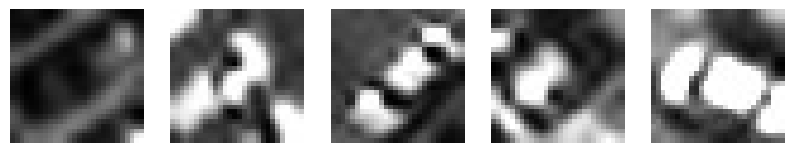

In [40]:
sample_car = load_images(car_images[:5])

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(sample_car[i], cmap='gray')
    plt.axis('off')
plt.show()

## Plane

In [41]:
plane_images = train_plane + test_plane

In [42]:
print("Total Plane Images:", len(plane_images))

Total Plane Images: 8020


to show 5 samples of the plane images

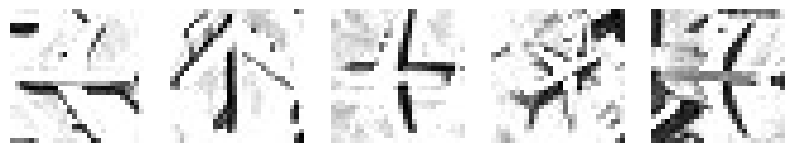

In [43]:
sample_plane = load_images(plane_images[:5])

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(sample_plane[i], cmap='gray')
    plt.axis('off')
plt.show()

# Combine Classes and Shuffle iImages

kedua kelas kemudian digabung menjadi satu data pool bersama, lalu diacak. pake shuffle

why is both class combined and shuffled then split again?

the autoencoder thats trained on mixed data will learn to represent different features of each classes in one latent layer of 128 dimensions. in order to do dimension reduction on both classes at once.


Both car and plane image paths are combined into a single list, then shuffled together before splitting. This ensures the model trains on a mixed dataset of both classes.

In [44]:
all_img = car_images + plane_images

In [45]:
len(all_img)

16032

In [46]:
all_img = shuffle(all_img, random_state = 42)

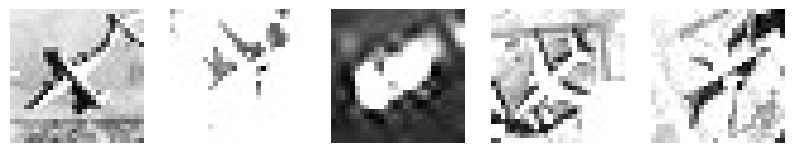

In [47]:
sample_img = load_images(all_img[:5])

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(sample_img[i], cmap='gray')
    plt.axis('off')
plt.show()

# Splitting Images


80% training set

20% valtest set --> in which will be divided again into
- 10% val
- 10% test

In [48]:
all_train_paths, all_valtest_paths = train_test_split(all_img,
                                                      test_size=0.2,
                                                      random_state=42)

splitting into
- 80% train
- 20% to validation AND testing

In [49]:
all_val_paths, all_test_paths = train_test_split(all_valtest_paths,
                                                 test_size=0.5,
                                                 random_state=42)

splitting the validation and testing dataset 50/50

- test 10% of overall amount
- validation 10% of overall amount

In [50]:
print("Train: ", len(all_train_paths))
print("Val: ", len(all_val_paths))
print("Test: ", len(all_test_paths))

Train:  12825
Val:  1603
Test:  1604


In [51]:
X_train = load_images(all_train_paths)
X_val = load_images(all_val_paths)
X_test = load_images(all_test_paths)

In [52]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12825, 28, 28)
(1603, 28, 28)
(1604, 28, 28)


the shape of tyhe split data is already consistent for each different split

# Normalisation

Nilai piksel dinormalisasi dari 0, 255 ke 0, 1 denganby dividing it by 255

for consistency with the sigmoid activation function in the output decoder

- ensure stable training gradient

# Dimension Expansion

- np.expand_dims(..., axis=-1) menambah dimensi channel until it becomes (N, 28, 28, 1) --> which is the needed format for Conv2D

In [53]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [54]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [55]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12825, 28, 28, 1)
(1603, 28, 28, 1)
(1604, 28, 28, 1)


final check to the shape must be

(N, 28, 28,1)

# Making the BASELINE Model

arsitektur baseline untuk Dimension Reduction dari dimensi 784
(28x28) menjadi dimensi 128

evaluasi kualitas citra hasil decoder menggunakan Structural Similarity Index (SSIM) pada data test

Autoencoder compresses input

- 784 dimensions (28×28×1) to 128 dimensi (latent space)
- then reconstructs it back into the original size


1. Encoder: Input(28,28,1) --> Conv2D(32) -->  MaxPool(2×2) --> Flatten -->Dense(128)

2. Decoder: Dense(6272) --> Reshape(14,14,32) --> UpSampling(2×2) --> Conv2D(32) --> Conv2D(1, sigmoid)



- Conv2D + MaxPooling: extracts spacial features and compresses them step by step
- Dense(128): for the dimension reduction of 784 to 128
- UpSampling2D: the opposite of MaxPooling to restore spatial resolution
- sigmoid output + binary_crossentropy loss: every pixel is treated as a binary variable between 0 and 1

In [56]:
input_img = Input(shape=(28, 28, 1))

#en code
x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(pool_size=(2,2))(x)

x = Flatten()(x)

latent = Dense(
    128,
    activation='relu',
    name='latent'
)(x)


#de code
x = Dense(14*14*32)(latent)

x = Reshape((14,14,32))(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(x)

decoded = Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

## Training

In [58]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.5344 - val_loss: 0.4936
Epoch 2/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4816 - val_loss: 0.4765
Epoch 3/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4688 - val_loss: 0.4677
Epoch 4/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4621 - val_loss: 0.4646
Epoch 5/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4587 - val_loss: 0.4654
Epoch 6/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4565 - val_loss: 0.4592
Epoch 7/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4551 - val_loss: 0.4576
Epoch 8/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4538 - val_loss: 0.4575
Epoch 9/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4527 - val_loss: 0.4560
Epoch 10/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4518 - val_loss: 0.4550
Epoch 11/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4515 - val_loss: 0.4551
Epoch 12/40
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/st

In [59]:
decoded_imgs = autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


## Evaluation with SSIM

SSIM (Structural Similarity Index Measure)

- measure structural similarity between real image ans reconstructed image between:
- -1
- 1 where 1 = perfect reconstruction

SSIM accounts for luminance, contrast and structure together --> for visual images

In [60]:
scores = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].squeeze(),
        decoded_imgs[i].squeeze(),
        data_range=1.0
    )
    scores.append(score)

print("Average Baseline SSIM:", np.mean(scores))

Average Baseline SSIM: 0.7647946693444314


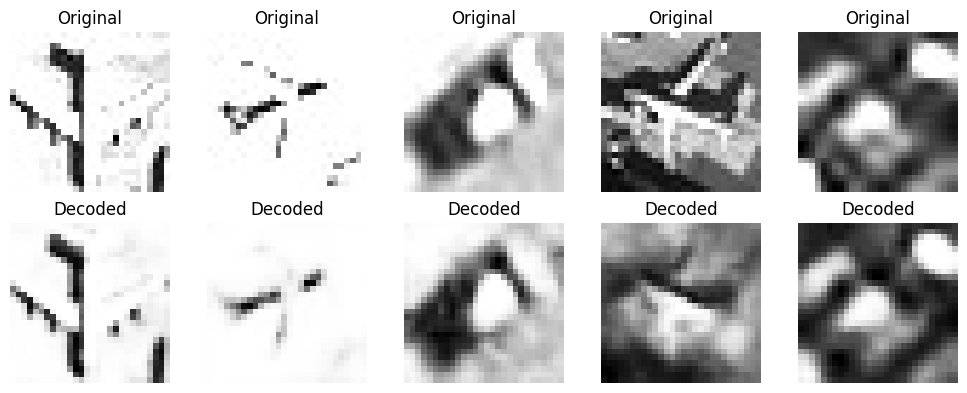

In [61]:
n = 5

plt.figure(figsize=(10,4))

for i in range(n):

    #ori image
    plt.subplot(2,n,i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    #recon imaghe
    plt.subplot(2,n,i+n+1)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.tight_layout()
plt.show()

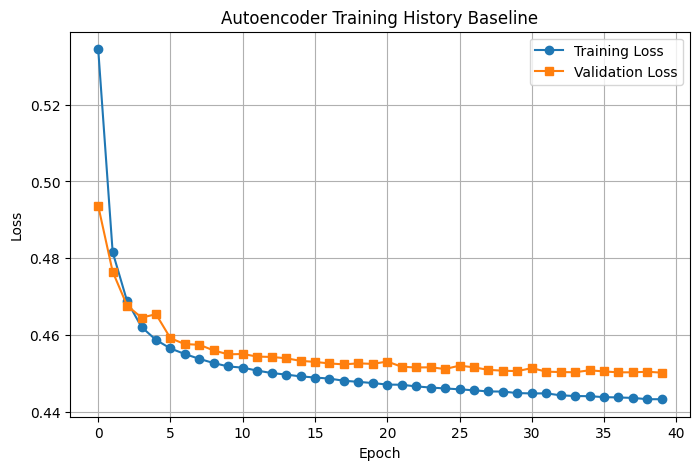

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='s', label='Validation Loss')

plt.title('Autoencoder Training History Baseline')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## Baseline Model EVAL

Training and validation loss are close together the entire run. the gap between train and vall loss is vey small ~ 0.005 (?). Both converges and plateau around epoch 25, settling at ~0.440 (train) and ~0.448 (val). there are little to no overfitting seen in the graph.

However, the model stops meaningfully improving well before epoch 40

the last ~10 epochs are wasted in a way

!! EARLY STOPPING need to be placed in modified model

SSIM of 0.79 tells us that theres a moderately good level of similarity between the original and the decoded images.

as seen in the sample above, images 1, 3, and 5 is decently replicated in the decoded images, however for images 2 and 4, when the initial image has an unclear luuminance or structural aspects in which the model may confuse the two, the decoded images reduces the quality

# Making the MODIFIED Model

conv encoder is now 2 layers from 32 in the baseline to 64

the bottleneck then now has to be flattening from 256 to 128

and the decoder from
128 --> 256 --> 12544

the conv decoder now has 3 layers, from the 2 only in baseline

modified conv decoder works from 64 to 32 to 1 output

Learning rate:
0.001 --> 0.0005
- slower, smoother learning curves

Batch size
64 --> 32
- more often gradient updates and expect better generalisation


Epochs
40 --> 80
- more iterations needed with the current learning rate and smaller batch size

Early stopping
now have patience = 10
- to restore the best weight and the val loss is stagnant

ReduceLOnPlateau
now we have factor = 0.5 and patience = 5

Setelah mengetahui hasil dari nomor (2b), modifikasi arsitektur
Autoencoder di atas agar mendapatkan representasi Dimension Reduction yang optimal
dengan membandingkan hasil Structural Similarity Index (SSIM) nya. Dan selanjutnya lakukan
proses tuning hyperparameter agar unjuk kerjanya meningkat. Berikan alasan mengapa
modifikasi arsitektur dan metode tuning hyperparameter kalian lebih baik.

In [63]:
input_img = Input(shape=(28,28,1))

#en code
x = Conv2D(32,3,padding='same',activation='relu')(input_img)
x = Conv2D(64,3,padding='same',activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dense(256,activation='relu')(x)

latent = Dense(128,activation='relu')(x)

#de code

x = Dense(256,activation='relu')(latent)

x = Dense(14*14*64)(x)

x = Reshape((14,14,64))(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(64,3,padding='same',activation='relu')(x)
x = Conv2D(32,3,padding='same',activation='relu')(x)

decoded = Conv2D(1,3,padding='same',activation='sigmoid')(x)

improved_autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865,669 (18.56 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,243,780 (12.37 MB)

### Tuning

In [64]:
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
EPOCHS = 100

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

improved_autoencoder.compile(
    optimizer=optimizer,
    loss='binary_crossentropy'
)




earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [65]:
history_improved = improved_autoencoder.fit(
    X_train,
    X_train,

    validation_data=(
        X_val,
        X_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        earlystop,
        reduce_lr
    ]
)

Epoch 1/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.5358 - val_loss: 0.4944 - learning_rate: 5.0000e-04
Epoch 2/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4803 - val_loss: 0.4747 - learning_rate: 5.0000e-04
Epoch 3/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4666 - val_loss: 0.4656 - learning_rate: 5.0000e-04
Epoch 4/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4594 - val_loss: 0.4602 - learning_rate: 5.0000e-04
Epoch 5/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4550 - val_loss: 0.4571 - learning_rate: 5.0000e-04
Epoch 6/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4517 - val_loss: 0.4544 - learning_rate: 5.0000e-04
Epoch 7/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4492 - val_loss: 0.4529 - learning_rate: 5.0000e-04
Epoch 8/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4471 - val_loss: 0.4516 - learning_rate: 5.0000e-04
Epoch 9/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4455 - val_loss

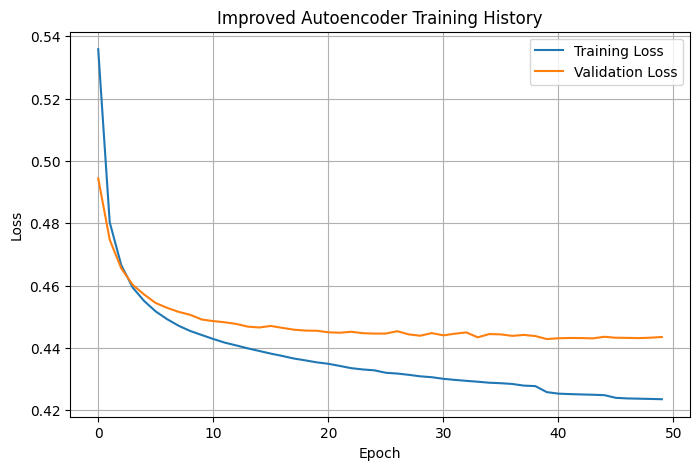

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title('Improved Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [67]:
decoded_imgs_improved = improved_autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [68]:
scores = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        decoded_imgs_improved[i].squeeze(),
        data_range=1.0
    )

    scores.append(score)

avg_ssim = np.mean(scores)

print(f"Average Modified SSIM: {avg_ssim:.4f}")

Average Modified SSIM: 0.8260


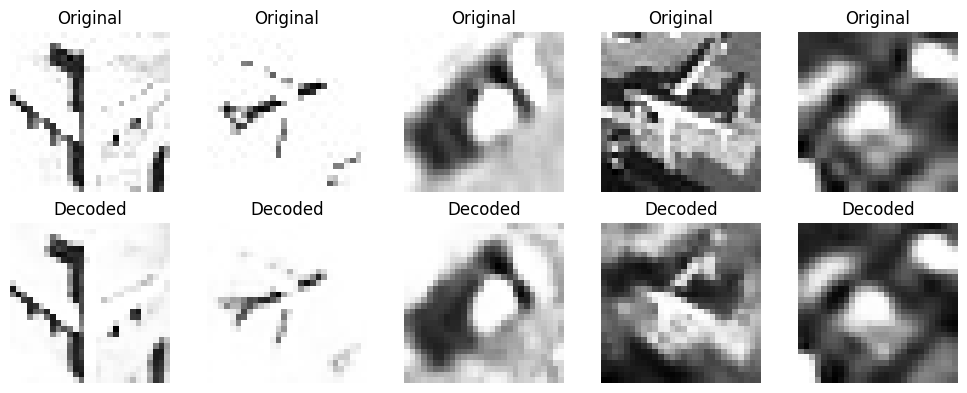

In [69]:
n = 5

plt.figure(figsize=(10,4))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(decoded_imgs_improved[i].squeeze(), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Modif Model EVAL

the train and val loss diverge noticeably after epoch ~10.

Training loss keeps dropping steadily to ~0.424, while validation plateaus around ~0.442

there is a consistent gap of ~0.018 between train and val loss. which may indicate small overfitting, but the SSIM improvement on the test set tells us that its still generalizing well, with meaning

the modified architecture have the capacity to keep fitting the training data beyond what generalises.

The ReduceLROnPlateau is visible in the training curve as the slope gradually flattens rather than hitting a hard plateau

the learning rate  was being reduced progressively.

Early stopping happens in around epoch 48 instead of running the full 80.

SSIM improves to 0.8356, +0.0425 of the baseline. the model learned better representations instead of plainly memorizing and overfitting.

the deeper encoder made more meaningfull, deeperk feature hierarchies before it bottlenecks, now the encoded images have better structural preservations

ReduceLROnPlateau helps model automatically fine tunes, while EarlyStopping preventspotential overfitting as well.

# NUMBER 3

Deep Learning mengalami perkembangan yang sangat pesat
dalam beberapa tahun belakangan ini. Salah satunya dalam bidang Generative AI. Cikal bakal dari
bidang ini adalah arsitektur yang disebut sebagai generative adversarial network

a. [LO 1, LO 2, LO 3, 5 poin] Jelaskan cara kerja dari arsitektur tersebut yang dideskripsikan dalam
gambar di bawah ini:

refer to the picture in the exam docs

CARA KERJA GAN

Generative Adversarial Network or GAN works by connecting 2 neural networks that are trained adversarially --> oppositely, they work in the opposite way to one another, generator and discriminator


1. Generator

accepts input such as random noise, random vector thats usually from a gaussian or uniform distrinbution. then the generator with hidden layers will produce an output of a fake image --> synthetic image. the generator never seen the real data but it only aims to "trick" the discriminator.

2. Discriminator

the discriminator takes in 2 input, the real data from the training set and the fake data from the generator, then it'll predict if the immage is fake = 0, or real = 1. what the generator wants, is to make discriminator think that the generated image is real.


Training the DISCRIMINATOR
1. take in a  batch of real images from the training set in which it labels --> Real = 1

2. take in the false generated batch of images from the generators, in which it labels fake = 0

3. calculate the loss of the discriminator and update the weights so it can differentiate real and fake images through mathematical, numerical, approaches


Training the GENERATOR
1. pause the discriminator
2. generate a false image and feed it to the discriminator input
3. generator will receive a loss value that indicates how many times the DISCRIMINATOR correctly labels the generated image as "Fake". Generator wants Discriminator to think it is a real image.
4. update the weights of the generator


LOSS FUNCTION

min_G max_D [ E[log D(x)] + E[log(1 - D(G(z)))] ]

Discriminator D --> mazimalize the likelihood of detecting a real image as real and a fake image as fake
Generator G --> minimalise the probability that the generated image is labeled as fake

Generator wants D(G(z)) to get close to 1

TRAINING ENDS WHEN
1. the generator have generated images with similar distributions to the real data
2. discriminator cannot differentiate real images and fake images. and can only guess with a probability of 0.5


Buatlah arsitektur untuk image generation sesuai dengan gambar arsitektur
GAN berikut ini. Lakukan evaluasi kesamaan distribusi citra dengan menggunakan Fréchet Inception
Distance (FID) pada data test.

## GAN Image Arcitechture


we're still pulling the data from the same source

copy the labels.csv from archive2 to colab

In [70]:
!cp "/content/drive/MyDrive/Dataset_NO2_UAS_DL/version2/labels.csv" /content/labels.csv

In [71]:
labels_df = pd.read_csv('/content/labels.csv')
print(labels_df.head(10))
print("\nUnique classes:", labels_df['class'].unique())
print("Label mapping:\n", labels_df[['label','class']].drop_duplicates().sort_values('label'))

   label          class      image dataset
0      6    runway_mark  00001.jpg   train
1      0            car  00002.jpg   train
2      4    parking_lot  00003.jpg   train
3      3  oil_gas_field  00004.jpg   train
4      8        stadium  00005.jpg   train
5      5          plane  00006.jpg   train
6      7           ship  00007.jpg   train
7      4    parking_lot  00008.jpg   train
8      0            car  00009.jpg   train
9      2     helicopter  00010.jpg   train

Unique classes: ['runway_mark' 'car' 'parking_lot' 'oil_gas_field' 'stadium' 'plane'
 'ship' 'helicopter' 'harbor' 'storage_tank']
Label mapping:
     label          class
1       0            car
14      1         harbor
9       2     helicopter
3       3  oil_gas_field
2       4    parking_lot
5       5          plane
0       6    runway_mark
6       7           ship
4       8        stadium
32      9   storage_tank


# Load Extra Libraries for cGAN

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.utils as vutils
from scipy import linalg
from torchvision.models import inception_v3
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


### Data Prep for CGAN

cgan need a pair of input, image and the label. we need to combine the right images with the right labels.

dataset we're still using classes car and plane.


In [73]:
car_pairs   = [(p, 0) for p in car_images]
plane_pairs = [(p, 5) for p in plane_images]

all_pairs = car_pairs + plane_pairs
import random
random.seed(42)
random.shuffle(all_pairs)

print(f"Total pairs: {len(all_pairs)}")
print(f"Car: {len(car_pairs)}")
print(f"Plane: {len(plane_pairs)}")

Total pairs: 16032
Car: 8012
Plane: 8020


### Splitting for train val test

train 80%
test 10%
val 10%

In [74]:
n = len(all_pairs)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

In [75]:
cgan_train = all_pairs[:n_train]
cgan_val = all_pairs[n_train : n_train + n_val]
cgan_test = all_pairs[n_train + n_val:]

In [76]:
print("Train:", len(cgan_train))
print("Val:", len(cgan_val))
print("Test:", len(cgan_test))

Train: 12825
Val: 1603
Test: 1604


# NOW we make the LABELED dataset

In [77]:
class OverheadDataset(Dataset):
    def __init__(self, pairs, img_size=28):
        self.pairs    = pairs
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),# HxW --> 1xHxW, [0,1]
            transforms.Normalize([0.5], [0.5])  # [-1, 1] for tanh output
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, label = self.pairs[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

IMG_SIZE   = 28
BATCH_SIZE = 64
N_LABELS   = 2 #car and plane only --> remap to 0 and 1

#remap labels: car(0) --> 0, plane(5) --> 1
label_map = {0: 0, 5: 1}

def remap(pairs):
    return [(p, label_map[l]) for p, l in pairs]

train_ds = OverheadDataset(remap(cgan_train), IMG_SIZE)
val_ds   = OverheadDataset(remap(cgan_val),   IMG_SIZE)
test_ds  = OverheadDataset(remap(cgan_test),  IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 201 | Val batches: 26 | Test batches: 26


# CGAN building

based on the diagram below

generator --> receives noise and label embedded

then there are linear layers
- 128
- 256
- 512
- 1024
- image size ^2

then fake images are generated


discriminator --> takes in image and label embedding

linear layers to predict if its real or fake


activation layer
1. Generator
- leakyrelu
- tanh for the output

2. discriminator
- leaky relu same as the generator
- sigmoid in the output for actual probabilities

In [78]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, n_labels=N_LABELS, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + n_labels, 128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels) #(B, n_labels)
        x = torch.cat([noise, label_input], dim=1) # (B, noise+n_labels)
        out = self.net(x)
        return out.view(-1, 1, self.img_size, self.img_size)


class Discriminator(nn.Module):
    def __init__(self, n_labels=N_LABELS, img_size=IMG_SIZE):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.net = nn.Sequential(
            nn.Linear(n_labels + img_size * img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 1024),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        label_input = self.label_emb(labels) #(B, n_labels)
        img_flat    = imgs.view(imgs.size(0), -1) #(B, img_size2)
        x = torch.cat([img_flat, label_input], dim=1) #(B, img_size2 + n_labels)
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)

print("Generator:")
print(G)
print("\nDiscriminator:")
print(D)

Generator:
Generator(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

Discriminator:
Discriminator(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_feat

### CGAN Model Training

MEASURED IN

loss --> binary cross entropy
- output discriminator is in the probability between 0 and 1

optimizer --> adam with lr = 0.0002, and beta 1 = 0.5
- for stability of the training

noise dim --> 100
- a random vector to be the starting input if the generator

In [79]:
NOISE_DIM  = 100
LR         = 0.0002
EPOCHS_GAN = 50
N_LABELS   = 2

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

def sample_noise(n):
    return torch.randn(n, NOISE_DIM, device=device)

def sample_labels(n, n_labels=N_LABELS):
    return torch.randint(0, n_labels, (n,), device=device)

##### training loop

for each epoch u train D and G

D --> update with real images 1 and fake images 0

G --> train with loss of D when it classifies fake as real

In [80]:
G_losses, D_losses = [], []

for epoch in range(1, EPOCHS_GAN + 1):
    g_loss_epoch, d_loss_epoch = 0.0, 0.0

    for real_imgs, real_labels in train_loader:
        real_imgs   = real_imgs.to(device)
        real_labels = real_labels.to(device)
        batch_n     = real_imgs.size(0)

        real_targets = torch.ones(batch_n, 1, device=device)
        fake_targets = torch.zeros(batch_n, 1, device=device)

        #train disc
        opt_D.zero_grad()

        #ril
        d_real = D(real_imgs, real_labels)
        loss_d_real = criterion(d_real, real_targets)

        #fake
        noise      = sample_noise(batch_n)
        fake_labels = sample_labels(batch_n)
        fake_imgs  = G(noise, fake_labels).detach()
        d_fake     = D(fake_imgs, fake_labels)
        loss_d_fake = criterion(d_fake, fake_targets)

        loss_D = (loss_d_real + loss_d_fake) / 2
        loss_D.backward()
        opt_D.step()

        #train gen
        opt_G.zero_grad()

        noise       = sample_noise(batch_n)
        fake_labels = sample_labels(batch_n)
        fake_imgs   = G(noise, fake_labels)
        d_out       = D(fake_imgs, fake_labels)
        loss_G      = criterion(d_out, real_targets)

        loss_G.backward()
        opt_G.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()

    avg_g = g_loss_epoch / len(train_loader)
    avg_d = d_loss_epoch / len(train_loader)
    G_losses.append(avg_g)
    D_losses.append(avg_d)

    if epoch % 10 == 0 or epoch == 1:
        print("Epoch:", epoch, "/", EPOCHS_GAN, "Loss_D:", avg_d, "Loss_G:", avg_g)

Epoch: 1 / 50 Loss_D: 0.5583830892446622 Loss_G: 1.6067391384893388
Epoch: 10 / 50 Loss_D: 0.5094593822659544 Loss_G: 1.4152324991439706
Epoch: 20 / 50 Loss_D: 0.5019867403886804 Loss_G: 1.3765529720344354
Epoch: 30 / 50 Loss_D: 0.49562439070412173 Loss_G: 1.4096491995142466
Epoch: 40 / 50 Loss_D: 0.47046236701272615 Loss_G: 1.496720427897439
Epoch: 50 / 50 Loss_D: 0.4148328885510193 Loss_G: 1.7846460923626648


plotting graph for generator loss and discriminator loss

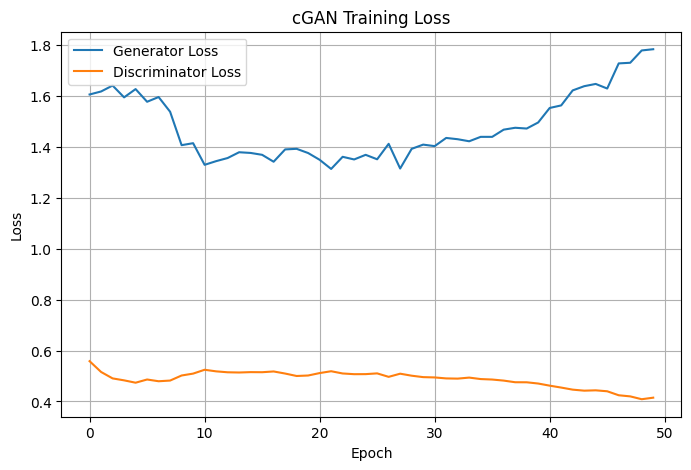

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.title('cGAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### OUTPUT GRAPH EVALUATION

the discriminator loss is dropping in a steady curve from around 0.55 to 0.40. which means the discriminator is improving in telling between the real and the fake images.

when discriminator improves the loss is given to the generator by loss_g.backward() it will propagate back through discriminator's weights into generator.

the discriminator is too confident on fake images correctly so that this gradient log(1-D(G(z))) is now due to all the correct predictions from discriminator

then the generator's learning does not improve, the mathematical loss function drops to zero. and since the gradients acts as feedback for the model to improve, if its 0, it stops improving or learning

when discrimninator drops below 0.5 and generator keep climbing, the generated images at epoch 50 can be either worse or no better than the generated images at epoch 15.

Discriminator punya 4 layer with dropout G meanwhile generator has 4 hidden layers with no regularisation

to see the generated images

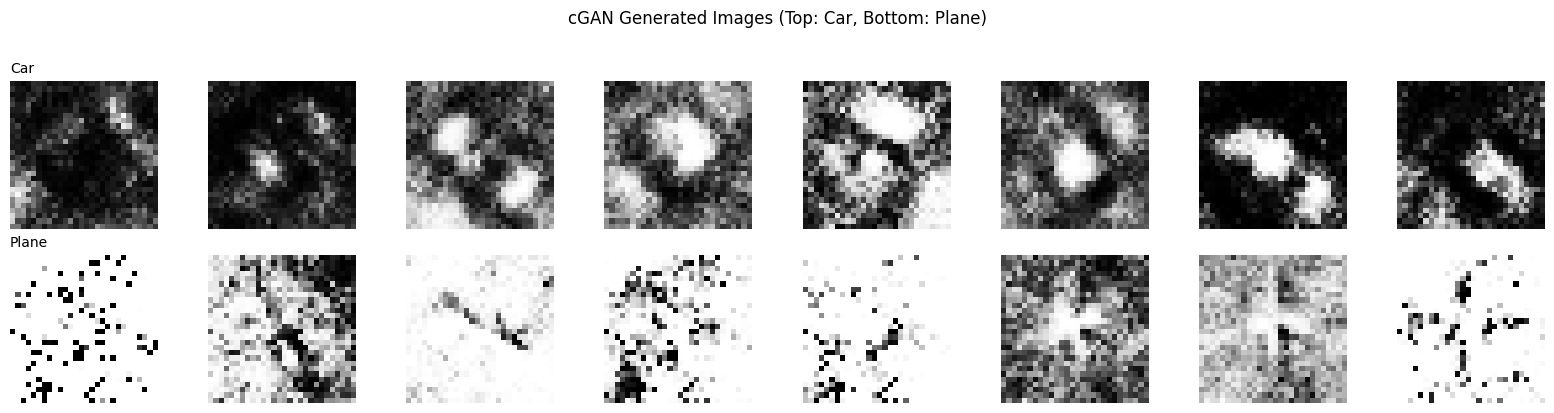

Generator(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

In [82]:
G.eval()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_names = {0: 'Car', 1: 'Plane'}

with torch.no_grad():
    for class_idx in range(N_LABELS):
        noise  = sample_noise(8).to(device)
        labels = torch.full((8,), class_idx, dtype=torch.long, device=device)
        imgs   = G(noise, labels).cpu() #(8, 1, 28, 28)
        imgs   = (imgs * 0.5 + 0.5).clamp(0, 1) #denormalize to [0,1]

        for j in range(8):
            axes[class_idx, j].imshow(imgs[j, 0], cmap='gray')
            axes[class_idx, j].axis('off')
            if j == 0:
                axes[class_idx, j].set_title(class_names[class_idx], fontsize=10, loc='left')

plt.suptitle('cGAN Generated Images (Top: Car, Bottom: Plane)', y=1.02)
plt.tight_layout()
plt.show()

G.train()

## FID EVALUATION

FID measures the distribution of the real images and the generated images


the feature distribution of fake and real is then modeled for the distribution of multivariable Gaussian with mean and covariance.

FID is calculated as the Fretchet distance between the distributions

buat data kita sekatang yang grayscale dan dimensi 28 x 28. which means that our pictures are quite representative of itself, becayse its just based on the pixel difference distribution where theres shape, contrast and bright or dark areas which is already okay in grayscale


we use the feature in our cnn and use the flattened pixel vetor as the feature representation directly.



the smaller the FID, the more similar the generated image distribution is to the real image distribution

usually FID < 50 is good and FID < 10 is very good

In [83]:
def get_pixel_features(imgs_tensor):

    n = imgs_tensor.shape[0]
    flat = imgs_tensor.view(n, -1).numpy()   # (N, 784)
    return flat


def compute_fid(real_feats, fake_feats):
    mu_r, sigma_r = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu_f, sigma_f = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)

    diff = mu_r - mu_f
    covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean)
    return float(fid)

taking the images from test set

In [84]:
real_imgs_list = []
with torch.no_grad():
    for imgs, _ in test_loader:
        real_imgs_list.append(imgs)

real_imgs_tensor = torch.cat(real_imgs_list, dim=0)

real_imgs_01 = (real_imgs_tensor * 0.5 + 0.5).clamp(0, 1)

print(f"Real test images: {real_imgs_01.shape}")

Real test images: torch.Size([1604, 1, 28, 28])


generate fake images

In [85]:
G.eval()
n_test   = len(real_imgs_01)
fake_imgs_list = []

with torch.no_grad():
    for i in range(0, n_test, BATCH_SIZE):
        n_batch = min(BATCH_SIZE, n_test - i)
        noise   = sample_noise(n_batch).to(device)
        labels  = sample_labels(n_batch)
        fakes   = G(noise, labels).cpu() #(-1, 1)
        fakes   = (fakes * 0.5 + 0.5).clamp(0, 1) #[0, 1]
        fake_imgs_list.append(fakes)

fake_imgs_01 = torch.cat(fake_imgs_list, dim=0)
print(f"Fake images generated: {fake_imgs_01.shape}")

G.train()

Fake images generated: torch.Size([1604, 1, 28, 28])


Generator(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

##### extract pixel features and calc FID

In [86]:
real_feats = get_pixel_features(real_imgs_01)
fake_feats = get_pixel_features(fake_imgs_01)

print(f"Real features shape: {real_feats.shape}")
print(f"Fake features shape: {fake_feats.shape}")

fid_score = compute_fid(real_feats, fake_feats)
print(f"\nFID Score (pixel-based, on test set): {fid_score:.2f}")

Real features shape: (1604, 784)
Fake features shape: (1604, 784)

FID Score (pixel-based, on test set): 27.73


##### FID VALUE EVAL


FID of 21.72 means that the mean and covariance of the generated images distribution is similar to the real test set pixel's distribution.

the generator is not generating random noise that would increase resulting FID but it does not give a perfect match of the real image either.

when the Generator's loss increased at the end of the plot, may explain the FID. the generator learned some clear distributions and statistic of some features, like for example the light and dark region, however it hasnt learned the finer details like structure or shape of each class

# Modified cGAN Building

to help the overpowering discriminator

the issue isnt in adding epochs, because more training will not help an oversaturated gradient

we add batchnormid for each layer except the first and the last to help stabilize the activation of G between layers. and to keep G learning

dropout to discriminator, add 0.4 dropout to discriminator in the middle of 2 layer. in hopes to stop Discriminator from being too confident, so the gradient can still be passed to generator for it to improve

separate learning rate the discriminator to 0.0001 and G to 0.0002 so that generator will learn a bit faster than discriminator, giving it time to adjust with the weights of a strong discriminator

In [87]:
class GeneratorModified(nn.Module):
    def __init__(self, noise_dim=100, n_labels=N_LABELS, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + n_labels, 128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([noise, label_input], dim=1)
        out = self.net(x)
        return out.view(-1, 1, self.img_size, self.img_size)

In [88]:
class DiscriminatorModified(nn.Module):
    def __init__(self, n_labels=N_LABELS, img_size=IMG_SIZE):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.net = nn.Sequential(
            nn.Linear(n_labels + img_size * img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 1024),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        label_input = self.label_emb(labels)
        img_flat    = imgs.view(imgs.size(0), -1)
        x = torch.cat([img_flat, label_input], dim=1)
        return self.net(x)


G_mod = GeneratorModified().to(device)
D_mod = DiscriminatorModified().to(device)

print("Generator (Modified):")
print(G_mod)
print("\nDiscriminator (Modified):")
print(D_mod)

Generator (Modified):
GeneratorModified(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

Discriminator (Modified):
DiscriminatorModified(
  (label_emb): Embedding(2, 2)
  (net

### Training

In [89]:
NOISE_DIM  = 100
LR_G       = 0.0002
LR_D       = 0.0001
EPOCHS_GAN = 50
N_LABELS   = 2
REAL_LABEL_SMOOTH = 0.9

criterion = nn.BCELoss()

opt_G_mod = optim.Adam(G_mod.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D_mod = optim.Adam(D_mod.parameters(), lr=LR_D, betas=(0.5, 0.999))

def sample_noise(n):
    return torch.randn(n, NOISE_DIM, device=device)

def sample_labels(n, n_labels=N_LABELS):
    return torch.randint(0, n_labels, (n,), device=device)

In [90]:
G_mod_losses, D_mod_losses = [], []

for epoch in range(1, EPOCHS_GAN + 1):
    g_loss_epoch, d_loss_epoch = 0.0, 0.0

    for real_imgs, real_labels in train_loader:
        real_imgs   = real_imgs.to(device)
        real_labels = real_labels.to(device)
        batch_n     = real_imgs.size(0)

        real_targets = torch.full((batch_n, 1), REAL_LABEL_SMOOTH, device=device)  # label smoothing
        fake_targets = torch.zeros(batch_n, 1, device=device)

        #disc
        opt_D_mod.zero_grad()

        d_real = D_mod(real_imgs, real_labels)
        loss_d_real = criterion(d_real, real_targets)

        noise       = sample_noise(batch_n)
        fake_labels = sample_labels(batch_n)
        fake_imgs   = G_mod(noise, fake_labels).detach()
        d_fake      = D_mod(fake_imgs, fake_labels)
        loss_d_fake = criterion(d_fake, fake_targets)

        loss_D = (loss_d_real + loss_d_fake) / 2
        loss_D.backward()
        opt_D_mod.step()

        #gen
        opt_G_mod.zero_grad()

        noise       = sample_noise(batch_n)
        fake_labels = sample_labels(batch_n)
        fake_imgs   = G_mod(noise, fake_labels)
        d_out       = D_mod(fake_imgs, fake_labels)
        loss_G      = criterion(d_out, torch.ones(batch_n, 1, device=device))  # G target tetap 1.0

        loss_G.backward()
        opt_G_mod.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()

    avg_g = g_loss_epoch / len(train_loader)
    avg_d = d_loss_epoch / len(train_loader)
    G_mod_losses.append(avg_g)
    D_mod_losses.append(avg_d)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS_GAN} Loss_D= {avg_d:.4f} Loss_G= {avg_g:.4f}")

Epoch 1/50 Loss_D= 0.6212 Loss_G= 1.3886
Epoch 10/50 Loss_D= 0.6008 Loss_G= 1.2833
Epoch 20/50 Loss_D= 0.6031 Loss_G= 1.2253
Epoch 30/50 Loss_D= 0.5794 Loss_G= 1.3012
Epoch 40/50 Loss_D= 0.5527 Loss_G= 1.4010
Epoch 50/50 Loss_D= 0.5254 Loss_G= 1.5186


#### Discriminator Loss and Gen Loss

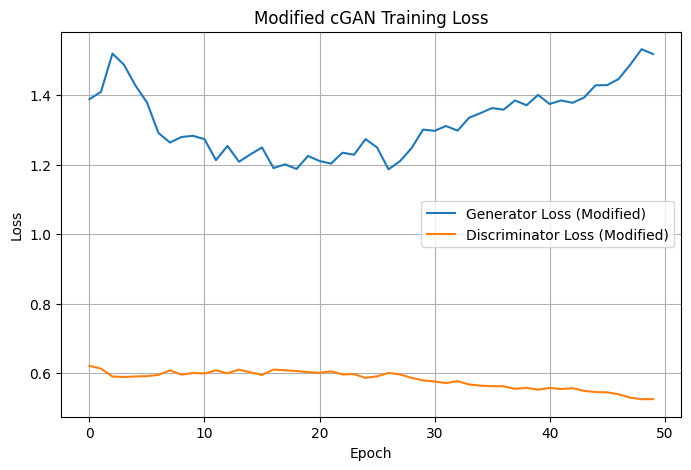

In [91]:
plt.figure(figsize=(8, 5))
plt.plot(G_mod_losses, label='Generator Loss (Modified)')
plt.plot(D_mod_losses, label='Discriminator Loss (Modified)')
plt.title('Modified cGAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

unfortunately the discriminator is still performing much better than the generator.

modified D dropped from 0.62 → 0.52 also ~0.10

D learning rate slowed its descent slightly, but didn't stop the trend. D's loss never plateaus or oscillates

it's declining in a curve the entire 50 epochs, meaning D keeps getting more confident while training.


Meanwhile Generators's loss bottoms out around epoch 18-20 at ~1.19, then climbs steadily back to ~1.5+ by epoch 50

this is still a similar shape to the baseline


the modified cgan arcitechture only lower starting Discriminator loss and slightly higher Generator floor but didn't change the underlying dynamic of a dominating discriminator




to visualise the generated images

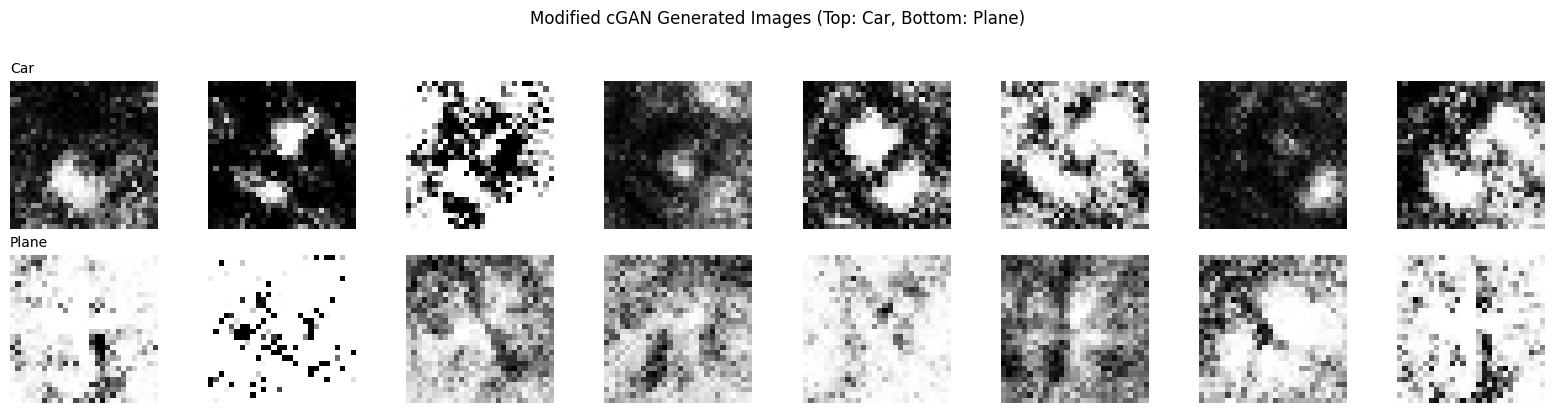

GeneratorModified(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

In [92]:
G_mod.eval()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_names = {0: 'Car', 1: 'Plane'}

with torch.no_grad():
    for class_idx in range(N_LABELS):
        noise  = sample_noise(8).to(device)
        labels = torch.full((8,), class_idx, dtype=torch.long, device=device)
        imgs   = G_mod(noise, labels).cpu()
        imgs   = (imgs * 0.5 + 0.5).clamp(0, 1)

        for j in range(8):
            axes[class_idx, j].imshow(imgs[j, 0], cmap='gray')
            axes[class_idx, j].axis('off')
            if j == 0:
                axes[class_idx, j].set_title(class_names[class_idx], fontsize=10, loc='left')

plt.suptitle('Modified cGAN Generated Images (Top: Car, Bottom: Plane)', y=1.02)
plt.tight_layout()
plt.show()

G_mod.train()

## FID Modif CGAN

In [93]:
G_mod.eval()
n_test_mod = len(real_imgs_01)
fake_imgs_mod_list = []

with torch.no_grad():
    for i in range(0, n_test_mod, BATCH_SIZE):
        n_batch = min(BATCH_SIZE, n_test_mod - i)
        noise   = sample_noise(n_batch).to(device)
        labels  = sample_labels(n_batch)
        fakes   = G_mod(noise, labels).cpu()
        fakes   = (fakes * 0.5 + 0.5).clamp(0, 1)
        fake_imgs_mod_list.append(fakes)

fake_imgs_mod_01 = torch.cat(fake_imgs_mod_list, dim=0)
print(f"Fake images generated (modified): {fake_imgs_mod_01.shape}")

G_mod.train()

Fake images generated (modified): torch.Size([1604, 1, 28, 28])


GeneratorModified(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

In [94]:
real_feats_mod = get_pixel_features(real_imgs_01)
fake_feats_mod = get_pixel_features(fake_imgs_mod_01)

fid_score_modified = compute_fid(real_feats_mod, fake_feats_mod)
print(f"FID Score Modified:   {fid_score_modified:.2f}")

FID Score Modified:   24.90


the FID of the modified model is larger than the baseline model. this indicates that some generated images are performing worse than the baseline cgan.

since generator's loss still ends up climbing and never recovers, the generator at epoch 50 is in a worse state than some earlier checkpoint

the discriminator is better to be reduced in capacity directly, meaning maybe less hidden layers between 256 and 512 instead of the one we made based on the image.

